### Making Figure 2

Christian Jorgensen

In [12]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from skimage import filters, morphology
from scipy.ndimage import generate_binary_structure, median_filter

In [2]:
#Load the raw output from the CT scanner
raw = nib.load("../Stelzer_Torsten/niis/CT_2025-03-03_11h19_Stelzer_capsule_1a_PEG_API.nii").get_fdata()[:, :, :]
raw -= raw.min()
slice = raw[:, :, 500]

In [3]:
raw.shape

(865, 748, 1948)

In [4]:
vmin = slice.min()
vmax = slice.max()

(np.float64(-0.5), np.float64(747.5), np.float64(864.5), np.float64(-0.5))

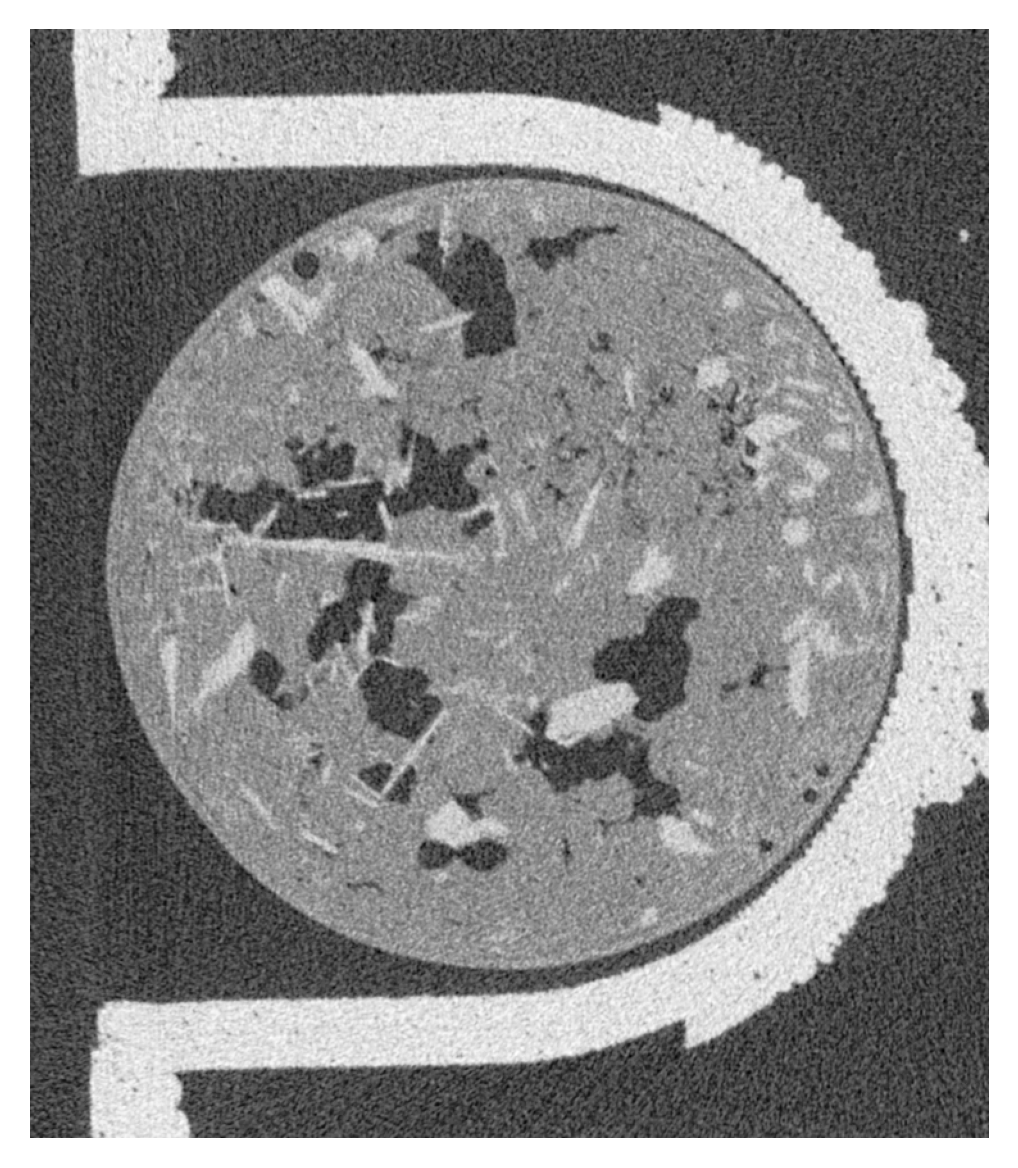

In [5]:
fig, ax = plt.subplots(1, 1, frameon=False, dpi=300)
ax.imshow(slice, cmap='Greys_r', vmin=vmin, vmax=vmax)
ax.axis('off')

In [6]:
del raw

In [8]:
sh_removed = np.load("../Stelzer_Torsten/npys/sh_removed_1a.npy")
sh_removed.shape

(1948, 865, 748)

In [9]:
slice2 = sh_removed[500, :, :]

(np.float64(-0.5), np.float64(747.5), np.float64(864.5), np.float64(-0.5))

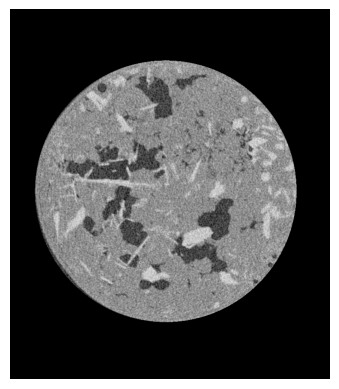

In [10]:
fig, ax = plt.subplots(1, 1, frameon=False)
ax.imshow(slice2, cmap='Greys_r', vmin=vmin, vmax=vmax)
ax.axis('off')

(np.float64(-0.5), np.float64(747.5), np.float64(864.5), np.float64(-0.5))

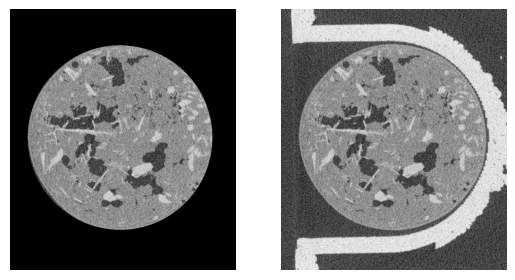

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, frameon=False)
ax1.imshow(slice2, cmap='Greys_r', vmin=vmin, vmax=vmax)
ax2.imshow(slice, cmap='Greys_r', vmin=vmin, vmax=vmax)
ax1.axis("off")
ax2.axis("off")

Next, show what the blurring looks like

In [13]:
sh_removed = median_filter(sh_removed, footprint=np.ones((3,3,3)))
sh_removed = median_filter(sh_removed, footprint=np.ones((3,3,3)))

In [14]:
slice3 = sh_removed[500, :, :].copy()

In [15]:
# Learn the first threshold via multiotsu, then learn the second via triangle
thresh1 = filters.threshold_multiotsu(sh_removed[sh_removed != -1], classes=3)[0]
foreground = sh_removed[sh_removed > thresh1]
thresh2 = filters.threshold_triangle(foreground)
regions = np.digitize(sh_removed, bins=[thresh1, thresh2])

In [16]:
del sh_removed

(np.float64(-0.5), np.float64(747.5), np.float64(864.5), np.float64(-0.5))

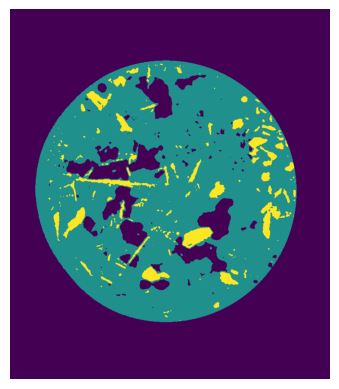

In [17]:
slice4 = regions[500, :, :].copy()
fig, ax = plt.subplots(1, 1, frameon=False)
ax.imshow(slice4)
ax.axis("off")

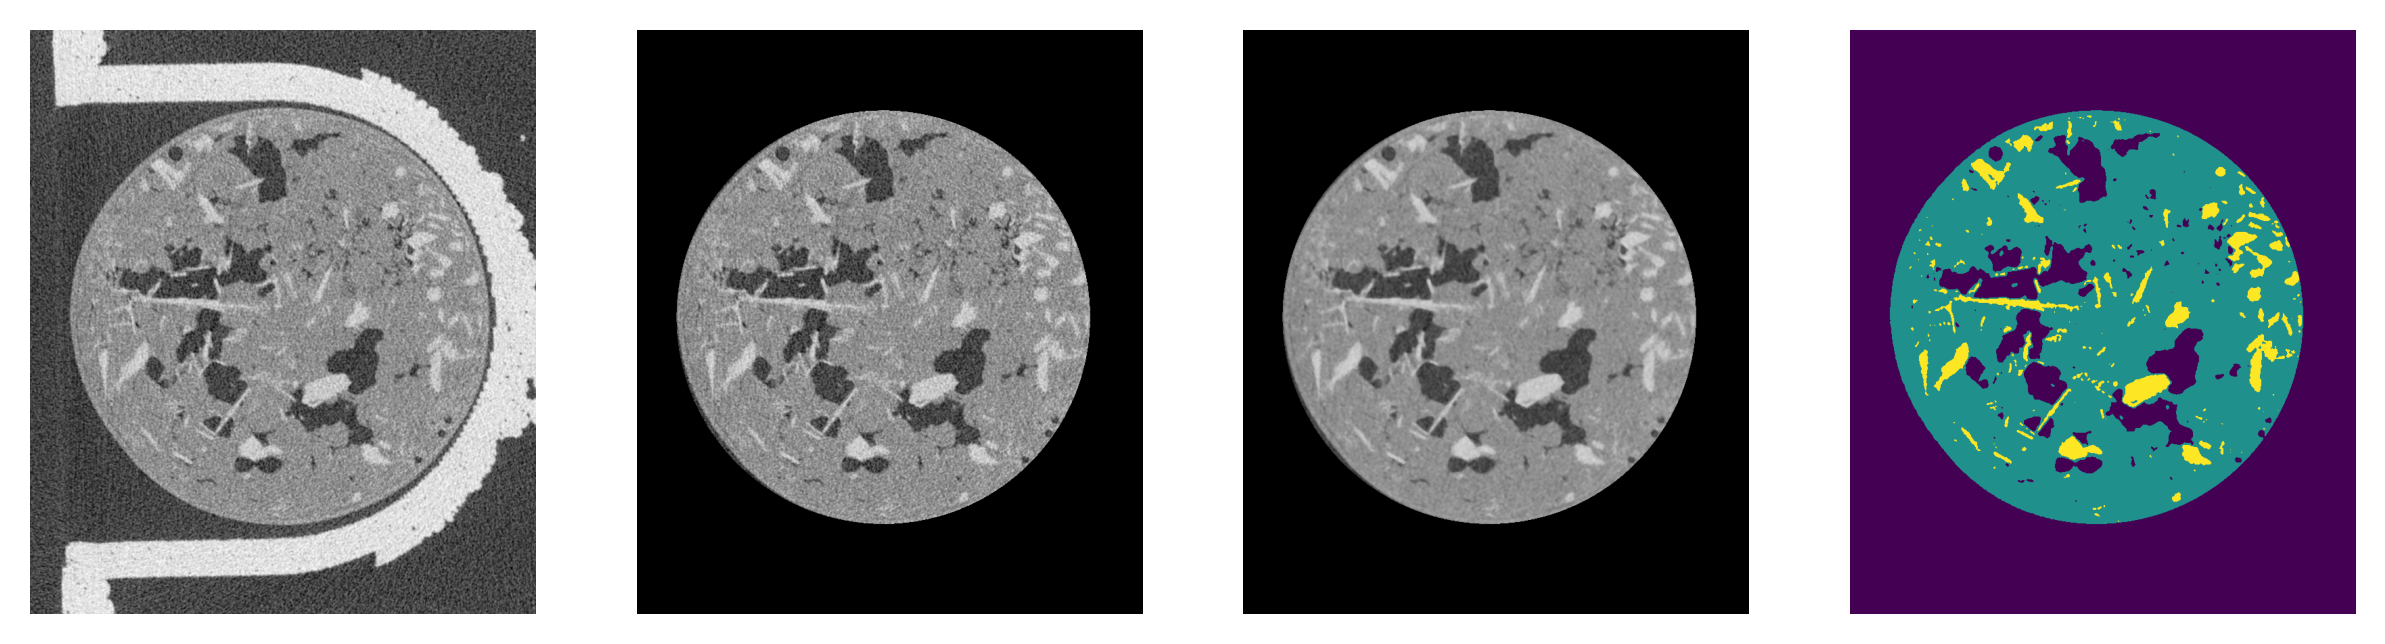

In [20]:
fig, axs = plt.subplots(1, 4, frameon=False, dpi=300, figsize=(10, 6))
axs[0].imshow(slice, vmin=vmin, vmax=vmax, cmap='Greys_r')
axs[1].imshow(slice2, vmin=vmin, vmax=vmax, cmap='Greys_r')
axs[2].imshow(slice3, vmin=vmin, vmax=vmax, cmap='Greys_r')
axs[3].imshow(slice4)
for ax in axs:
    ax.axis('off')

fig.savefig("imgs/2_capsule_preprocessing.png", dpi=300)